# Geometric GO

> Geometric genomic offset

The geometric genomic offset [@Gain_2023]

> ⚠️ Documentation is not complete yet!.

In [ ]:
#| default_exp geometric

In [ ]:
#| hide
#| export
from genomic_offsets.RidgeLFMM import *
from fastcore.utils import *
import statsmodels.api as sm
from nbdev.showdoc import *
from numba import njit, jit
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

A geometric genomic offset model has two hyperparameters: 
- $K$, the number of latent factors
- $\lambda$, a regularization . It is usually fixed to $10^{-5}$, intended to obtain an efficient analytical solution. This usage is similar to when fitting [logistic regressions where perfect separation](https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression). However, as far as I know, the effect of tuning this hyperparameter (doing cross-fold validation, for example), has not been explored yet. 

In [ ]:
#| export
class GeometricGO:
    "Geometric genomic offset statistic."
    def __init__(self, 
                 K: int, # Number of latent factors 
                 lambd: float): # Regularization parameter
        self.K = K
        self.lambd = lambd
        self._LFMM = None
        self._mx = None
        self._sx = None
        self.Cb = None
    def __str__(self):
        return f"Geometric genomic offset with K={self.K} and lambda={self.lambd}"
    __repr__ = __str__

In order to use the model we have first to initialize it:  

In [ ]:
model = GeometricGO(K=1, lambd=1e-5)

Then, we have to fit the model, that is ...

> ⚠️ Documentation is not complete yet!.

In [ ]:
#|export
@patch
def fit(self:GeometricGO,
        Y: np.ndarray, # Genotype matrix (nxL)
        X: np.ndarray): # Environmental matrix (nxP)
    "Fits the Geometric genomic offset model. "
    n1, L = Y.shape
    n2, P = X.shape
    if n1 != n2: 
        raise ValueError("Dimensions of array don't match")
    # Scale data and save it to predict later
    Y = Y - np.mean(Y, axis=0)
    mx = np.mean(X, axis=0)
    X = X - mx
    sx = np.std(X, axis=0)
    X = X / sx
    self._mx = mx
    self._sx = sx
    model = self._LFMM = RidgeLFMM(K=self.K, lambd=self.lambd)
    model.fit(Y=Y, X=X)
    self.Cb = np.dot(model.B.T, model.B) / model.B.shape[0]

The `fit()` method expects as input an genotype (or allele) matrix $\mathbf Y$ and an environmental matrix $\mathbf X$ with as many rows as individuals (or populations). For now, let us use the causal dataset we simulated in the previous section named [Simulations](simulation.html).  

In [ ]:
# If the package is intalled, the dataset 
# can be accessed with the commented code
#from genomic_offsets import datasets
#import importlib.resources 
# causal_dataset = np.load(importlib.resources.files(datasets).joinpath('causal.npz'))
causal_dataset = np.load("../genomic_offsets/datasets/causal.npz")

In [ ]:
# Read matrices
X, Xstar = causal_dataset["X"], causal_dataset["Xstar"]
Y = causal_dataset["Y"]
neglog_fitness = -np.log(causal_dataset["wstar"]+1e-5)
# Check dimensions
N, P = X.shape
assert Xstar.shape == (N, P)
assert Y.shape[0] == N

Let's split it into a train and test dataset: 

In [ ]:
rng = np.random.default_rng(1000) 
indices = rng.permutation(N)
training_idx, test_idx = indices[:60], indices[60:]
X_train, X_test = X[training_idx,:], X[test_idx,:]
Xstar_train, Xstar_test = Xstar[training_idx,:], Xstar[test_idx,:]
Y_train = Y[training_idx,:]
neglog_fitness_train, neglog_fitness_test =  neglog_fitness[training_idx], neglog_fitness[test_idx]

Let's fit the the LFMM model (that is the basis of the geometric genomic offset model) to the training dataset. In order to do so, we first have to remove un unvariable sites: 

In [ ]:
print(f"Shape before: {Y_train.shape}")
Y_train = Y_train[:, Y_train.var(axis=0) > 0]
print(f"Shape after: {Y_train.shape}")

Shape before: (60, 219)
Shape after: (60, 204)


In [ ]:
model.fit(Y_train, X_train)

The geometric genomic offset is built on top of a Latent Factor Mixed Model (LFMM) [@Caye_2019]. When fitting the LFMM model, not only the effect sizes of the environmental variables on the genotypes are estimated, but also the latent factors. These latent factors are encoded in a matrix $N\times L$ of rank $K$, where $N$ is the number of *training data points*. 

Therefore, it is not possible to predict the optimal genotypes for any dataset other than the one used to fit the model. Still, we can visualize the residuals to identify possible biases in the model. Please, refer to [the LFMM section of the documentation](LFMM.html) for more details. 

In [ ]:
#| hide
#| export
@patch
def _rescale_env(self:GeometricGO,
        X: np.ndarray, # Environmental matrix (nxP)
        )-> np.ndarray: # Re-scaled environmental matrix
    if self._mx is None or self._sx  is None: 
        raise ValueError("You have to fit the model first!")
    return (X-self._mx) / self._sx 

In [ ]:
#| export 
@patch
def predict(self:GeometricGO,
        X: np.ndarray # Environmental matrix (nxP)
           )-> np.ndarray: # Predicted allele frequencies
    "Predicts the *centered* optimal genotypes for the fitted environmental matrix."
    X = self._rescale_env(X)
    return self._LFMM.predict(X)

In [ ]:
import matplotlib.pyplot as plt

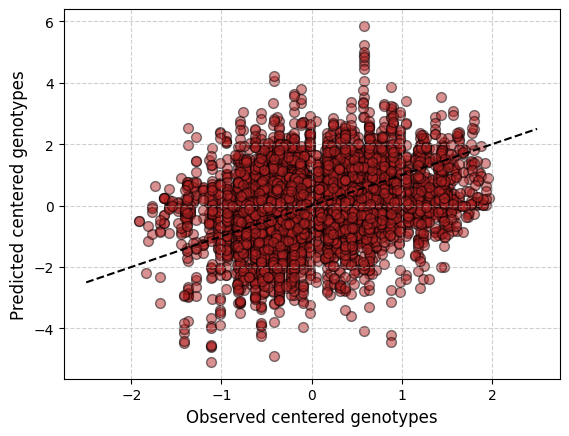

In [ ]:
centered_Y_train = Y_train - np.mean(Y_train, axis=0)
pred_Y_train = model.predict(X_train)
fig, ax = plt.subplots()
scatter = ax.scatter(
    centered_Y_train.reshape(-1),
    pred_Y_train.reshape(-1),
    c='firebrick', edgecolor='k',
    alpha=0.5, s=50
)
ax.plot([-2.5, 2.5], [-2.5, 2.5], ls="--", c="black")
ax.set_xlabel('Observed centered genotypes', fontsize=12)
ax.set_ylabel('Predicted centered genotypes', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


Finally, we can predict the genomic offset under two different environments: 

In [ ]:
#| hide
#| export
@njit
def genetic_gap(Cb: np.ndarray, X: np.ndarray, Xstar: np.ndarray) -> np.ndarray:
    offsets = np.zeros(X.shape[0])
    for i in range(len(offsets)):
        diff = X[i, :] - Xstar[i, :]
        offsets[i] = np.dot(np.dot(diff, Cb), diff.T)
    return offsets

In [ ]:
#| export 
@patch
def genomic_offset(self:GeometricGO,
        X: np.ndarray, # Environmental matrix (nxP)
        Xstar: np.ndarray, # Altered environmental matrix (nxP)
           )-> np.ndarray: # A vector of genomic offsets (n)
    "Calculates the genomic offset statistic. " 
    if X.shape != Xstar.shape: 
        raise ValueError("Dimensions of array don't match")
    return genetic_gap(self.Cb, self._rescale_env(X), self._rescale_env(Xstar))

As expected, the genomic offset is zero if both environmental matrixes are identical: 

In [ ]:
model.genomic_offset(X_train, X_train)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.])

First, let's compute the (causal) training genomic offset with the RDA model and measure its association with the training negative logarithm of altered fitness:  

In [ ]:
from scipy.stats import pearsonr

In [ ]:
training_offset = model.genomic_offset(X_train, Xstar_train)
pearsonr(training_offset, neglog_fitness_train)

PearsonRResult(statistic=np.float64(0.3085089208626329), pvalue=np.float64(0.01647366279612428))

Finally, let's compute the (still causal) test genomic offset (that is, a measure of decrease in fitness for all individuals we did not observe their genotypes and did not use to fit the model) 

In [ ]:
testing_offset = model.genomic_offset(X_test, Xstar_test)
testing_offset

array([5.99358002e-02, 3.23196322e+00, 1.22147908e-03, ...,
       2.02139448e+00, 3.26921400e-01, 3.59740259e-01])

In [ ]:
pearsonr(testing_offset, neglog_fitness_test)

PearsonRResult(statistic=np.float64(0.3288959943860878), pvalue=np.float64(2.5105495352866084e-70))

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()